# Chapter 3: Transformers

In the last chapter we saw how to use neural networks to model text. The LSTM was able to learn the structure of text with a larger context window size. However due to its recurrent nature, it requires to process the text sequentially in training and inference, which is not efficient. In this chapter we will see how to produce efficient models.

<img src="./img/bac.png" alt="Neuron" width="800" height="400">

The LSTM architecture maintains a hidden state and memory embeddings that are updated iteratively for each new token. This allows it to capture long-term dependencies but it is hard to parallelize the computations without taking advantage of current hardware capabilities to process multidimensional data. To improve the effectiveness of this model we will compute the memory and current state on the fly for each new token taking advantage of parallel computations.

## Attention is all you need

To compute the memory and current state for each new token, we need to be able to retrieve information from previous tokens in the sequence in an efficient way. Let's start simply by retrieving a token in a list and improve from it.

Consider the following list: [1, 4, 7, 6, 9, 2]. If the relevant token we want to retrieve is 7, we can search for its index using the list method `index`:

In [1]:
import math

tokenize = 7

sequence = [1, 4, 7, 6, 9, 2]

print(sequence.index(tokenize))

2


This search requires to iterate over the list until we find the token. If we have multiple lists to retrieve from, we also need to iterate over each list. This is not efficient to apply in our model. We need a way to find the relevant token index in parallel and potentially over multiple sequences.

Since our token is a number, we can compute the distance to each token and retrieve the position of the token with smaller distance. By computing this in PyTorch we can take advantage of parallel tensor computations to find the relevant token index in multiple sequences in parallel. We can use `argmax` function in PyTorch to get the index of the maximun value in a tensor. However, the distance to the relevant token is the minimum distance, so we can compute the inverse using this formula:

$$ score = \frac{1}{(token - token_{seq})^2 + 1} $$

Now if the distance is 0 (equal token) the score is 1 and gets smaller as the distance increases. Then we can compute the scores and get the index of the best match using `argmax` function:


In [2]:
import torch

tokenize = torch.Tensor([7])

sequence = torch.Tensor([1, 4, 7, 6, 9, 2])

score = 1 / ((tokenize - sequence)**2 + 1)

print(score)
print(score.argmax())

tensor([0.0270, 0.1000, 1.0000, 0.5000, 0.2000, 0.0385])
tensor(2)


This way we retrieved the information in parallel and the result is the same index from the list function. The same approach can be applied in multiple sequences to retrieve tokens from multiple sequences in parallel. We can also use this approach to retrieve multiple tokens from the same sequence in parallel.

If we don't have the exact token in the sequence we want to find the closest one. However, finding the index value of tokens doesn't give us relevant information since tokens next to each other in the vocabulary may have completely different meanings. So instead of working with scalar values, we can use the same operation in vector space. Since we can encode meaning in vectors by pointing similar concepts to the same direction, we can use the distance approach but comparing the angles between the vectors. Vectors pointing to the same direction must have a higher score (since they encode similar semantics) and we want the index of the most relevant vectors.

To convert the find operation to vector space we can use the dot product between the vectors instead of the distance formula. Let's take a look at the dot product formula:

$$ \vec{a} \cdot \vec{b} = |\vec{a}| |\vec{b}| \cos(\theta) $$

Where $\theta$ is the angle between the vectors. If the vectors point to the same direction, $\theta$ is 0 and $\cos(\theta)$ is 1, so the dot product is maximized as required from our search function. Note that we need to normalize the vectors to get the cosine similarity instead of the dot product. More on this later.

## Cross-attention

Now that we know how to retrieve information from a sequence in parallel, we need to know what information we want to retrieve. This operation of finding the relevant information and attending to it is called attention. To learn how the attention mechanism can be used to compute our current state and memory let's follow a simple example.

Consider the following problem: we have a list of 5 colors which 2 of them are random colors and the other 3 are the RGB channels of another random color. Our task is to find the RBG channels in the list such that when we combine them we get the original color. This is a simple problem but it has the same structure as the one we want to solve with attention. We have a list of tokens (colors) and we want to find the relevant tokens (RGB channels) to retrieve the information (original color). Let's start by generating our color dataset.

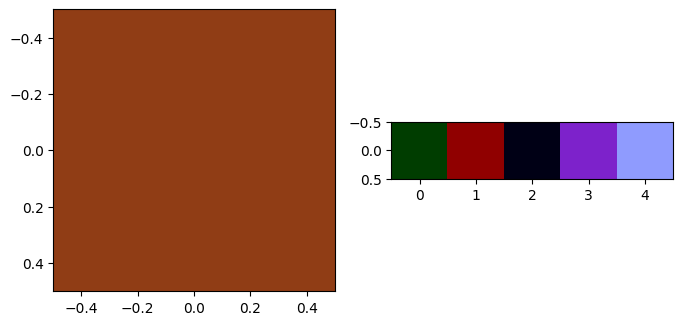

In [3]:
import matplotlib.pyplot as plt

# the main color
color1 = torch.rand(1, 1, 3)
# two random colors to mix with the main color channels
random_colors = torch.rand(1, 2, 3)

# we split the color channels and return the three channels as new colors
def split_rgb(t):
    r = torch.zeros_like(t)
    g = torch.zeros_like(t)
    b = torch.zeros_like(t)
    r[:, :, 0] = t[:, :, 0]
    g[:, :, 1] = t[:, :, 1]
    b[:, :, 2] = t[:, :, 2]
    return r, g, b

# add the main color channels to the random colors
color_sequence = torch.cat([random_colors, *split_rgb(color1)], dim=1)
# shuffle the colors
color_sequence = color_sequence[:, torch.randperm(color_sequence.shape[1]), :]

# show them
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(color1)
ax[1].imshow(color_sequence)

plt.show()

Here we are building one data line. We can put this procedure in a function to generate multiple data lines.

In [4]:
from torch.utils.data import TensorDataset

def build_color_dataset(count, sequence_size=5):
    color1 = torch.rand(count, 1, 3)
    random_colors = torch.rand(count, sequence_size - 3, 3)

    color_channels = split_rgb(color1)
    color_sequence = torch.cat([random_colors, *color_channels], dim=1)
    color_sequence = color_sequence[:, torch.randperm(color_sequence.shape[1]), :]
    return TensorDataset(color1, color_sequence)

dataset = build_color_dataset(200)

Now we can build our color retrieval model. For this model we can create three filters that will get the individual channels from the main color and we compare each channel against the random color sequence to retrieve the best candidates. Then we can combine the retrieved channels to get the original colors. In this approach our loss function will be the error from the original color to the reconstructed color from the random sequence.

Since this is a simple problem we can infer what the ideal filters would be. One approach is having one in the channel we are looking at and zero everywhere else. But in language it is hard to know what the ideal filters are, so in this example we can see that our attention mechanismo will learn by itself the best filters to retrieve the relevant information. Let's start by the filters:

In [5]:
import torch.nn as nn

# sample from our dataset
color1, sequence = dataset[0]

filter1 = nn.Linear(3, 3)
filter2 = nn.Linear(3, 3)
filter3 = nn.Linear(3, 3)

q1 = filter1(color1)
q2 = filter2(color1)
q3 = filter3(color1)

print(q1)
print(q2)
print(q3)

tensor([[-0.9658,  0.8671, -1.0881]], grad_fn=<AddmmBackward0>)
tensor([[-0.9542,  0.7626, -0.2791]], grad_fn=<AddmmBackward0>)
tensor([[-0.0325, -0.3383,  0.3754]], grad_fn=<AddmmBackward0>)


Since our filters start by random weights, the retrieved information is not each color channel as we are expecting. Then we can compute the similarity of each channel to the random sequence to retrieve the components. At the beginning the retrieved color is wrong, but by applying backpropagation our model will learn to correctly find the promising filters. Those filters are called attention heads and the attention with multiple heads is called multi-head attention (MHA). In our example, we have 3 heads each one with 3 dimensions.

Now, for simplicity, let's use the distance formula instead of the dot product to compute the similarity since we don't need to compute the vector norms. Also, since our score is over 3 dimensions, the final score is the sum of the scores of each dimension:

$$ score = \sum_{i=1}^{3} \frac{1}{(q_i - c_i)^2 + 1} $$

Where $q_i$ is the output of the filter for the channel we are looking at and $c_i$ is the color channel from the random sequence. We can compute this score for each filter and each color in the random sequence to retrieve the best candidates for each channel.

In [6]:
def compute_score(color, sequence):
    score = 1 / ((color - sequence) ** 2 + 1)
    return torch.sum(score, dim=-1)

score1 = compute_score(q1, sequence)
score2 = compute_score(q2, sequence)
score3 = compute_score(q3, sequence)

print(score1)
print(score2)
print(score3)

tensor([1.5122, 1.6449, 1.6554, 1.2906, 1.3047], grad_fn=<SumBackward1>)
tensor([2.0277, 2.1878, 1.9670, 1.8246, 1.6111], grad_fn=<SumBackward1>)
tensor([2.0069, 2.6735, 2.3250, 2.4167, 2.7346], grad_fn=<SumBackward1>)


Now we get the color with highest score in each channel and combine them to produce the final color.

In [7]:
print(score1.argmax(), score2.argmax(), score3.argmax())

best_color1 = sequence[score1.argmax(), :]
best_color2 = sequence[score2.argmax(), :]
best_color3 = sequence[score3.argmax(), :]

final_color = best_color1 + best_color2 + best_color3
print('Main color:\n', color1)
print('Reconstructed color:\n', final_color)

tensor(2) tensor(1) tensor(4)
Main color:
 tensor([[0.7128, 0.1647, 0.8145]])
Reconstructed color:
 tensor([0.2356, 0.9356, 1.4342])


Now we can put everything into a multi head attention class to start our training. However, we have some important points to consider before starting the training. First of all, let's take a look at the argmax gradient:

In [8]:
x = color1.clone()
x.requires_grad = True

# show the grad_fn since our color now requires grad
print(x + 1)

score = compute_score(x, sequence)
# our score also have a grad_fn
print(score)

# now the argmax
print(score.argmax())

tensor([[1.7128, 1.1647, 1.8145]], grad_fn=<AddBackward0>)
tensor([2.4903, 2.2643, 2.5092, 2.5748, 2.6366], grad_fn=<SumBackward1>)
tensor(4)


And here is the problem. The argmax function is not differentiable. This means that we can't backpropagate the error from the final color to the filters weights. We need to use a diferentiable argmax function. And the alternative is to use the soft argmax function that gives us a higher value at the index of the max value and lower values everywere else. This function is the softmax function we applyed in previous chapters to compute the probability distribution over the next tokens. Since the softmax adds to 1 it follows to rules of a probability distribution and also gives us the soft version of the argmax that is diferentiable.

Then, using softmax we will have a weighted sum over the sequence colors instead of getting only the maximum score color. Since we will use this attention for other purposes, the color we are searching for is called query, the sequence of colors we are searching for is the keys and the colors we are retrieving by multiplying the scores by the sequence colors are called values. In our case, the keys and values are the same but in other applications is possible that we search using one criteria that is different from the information we are retrieving.

With the softmax attention scores we can use it to compute our final color. Before that we need just to change our score function to add a small value $\beta$ to avoid division by zero instead of 1 since we have now higher values to work with the softmax function:

$$ score = \sum_{i=1}^{n_{dim}} \frac{1}{(q_i - c_i)^2 + \beta} $$

Another improvement is that if we need to add more channels we don't want to write more code to compute the extra head scores. So we will join multiple channels in one weight to compute then in parallel with the same code. Putting everything together we have the MHA class:

In [9]:
class MHA(nn.Module):
    def __init__(self, heads=1, n_dim=1, beta=0.1):
        super(MHA, self).__init__()
        # we join the heads in one weight to compute them in parallel
        self.filter = nn.Linear(n_dim, heads * n_dim)
        self.heads = heads
        self.n_dim = n_dim
        self.beta = beta

    def forward(self, x, y, return_score=False):
        # by applying the filters to the color we are searching for we have the query
        query = self.filter(x)

        # splitting the heads into a new dimension
        split_query = torch.unflatten(query, 2, (-1, self.n_dim))
        # we add another dimension in the sequence colors for broadcasting
        split_keys = y.unsqueeze(-2)

        # now we rearrange our dimensions to move the head dimension near to the batch dimension
        # before (batch, sequence, head, dims) after (batch, head, sequence, dim)
        split_query = split_query.permute(0, 2, 1, 3)
        split_keys = split_keys.permute(0, 2, 1, 3)

        # computing the attention scores using our score function
        attention_score = 1 / (torch.sum(torch.pow(split_query - split_keys, 2), dim=-1) + self.beta)

        # no derivative for argmax, use soft argmax instead (softmax)
        attention_score = torch.softmax(attention_score, dim=-1)

        # our values are equal to the keys
        split_values = y.unsqueeze(1)

        # weighted sum
        out = attention_score.unsqueeze(-1) * split_values
        # combine all the heads
        head_sum = torch.sum(out, dim=-2)
        # combine the colors in the sequence to have the final color
        sequence_sum = torch.sum(head_sum, dim=1, keepdim=True)

        # return the attention matrix for debbuging
        if return_score:
            return sequence_sum, attention_score
        else:
            return sequence_sum

Now we can start the training of our MHA model. We will use the mean squared error loss between the original color and the reconstructed color to train our model. We will also plot the loss curve to see how our model is learning.

  0%|          | 0/60000 [00:00<?, ?it/s]

0.00022400432348986793


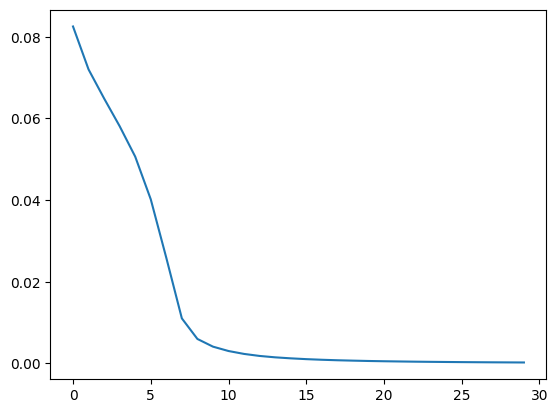

In [10]:
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm.auto import tqdm


def train(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, y)
            loss = crit(out, x)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh


mha = MHA(heads=3, n_dim=3)
dataset = build_color_dataset(2000)
lh = train(mha, dataset, epochs=30, lr=0.001, batch_size=32)
# last loss
print(lh[-1])
plt.plot(lh)

plt.show()

Our model converged and now we can check how well is it reconstructing the original color by selecting its channels in the colors list.

In [11]:
color1, sequence = dataset[0]

print('Original color:\n', color1)
print('Reconstructed color:\n', mha(color1.unsqueeze(0), sequence.unsqueeze(0)))

Original color:
 tensor([[0.3440, 0.4837, 0.5160]])
Reconstructed color:
 tensor([[[0.3492, 0.4851, 0.5181]]], grad_fn=<SumBackward1>)


The reconstructed color is near the original color, showing that our approach works. Let's verify the learned filters and the attention scores to confirm our hypothesis that the model is learning to attend to the correct channels.

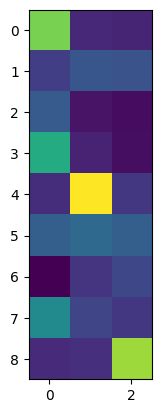

In [12]:
plt.imshow(mha.filter.weight.data)
plt.show()

The query filter weights is similar to what we expected. Since it is a matrix composed by three heads, each one with three dimensions, we can see that each head has a high value in one of the dimensions and low values in the other two dimensions. After the matrix multiplication, the resulting values will be selecting one of the channels and ignoring the other two. Remember that since the weights are initialized with random values, each time you train the network in the same data the position of the filters can change.

Let's check the attention scores:

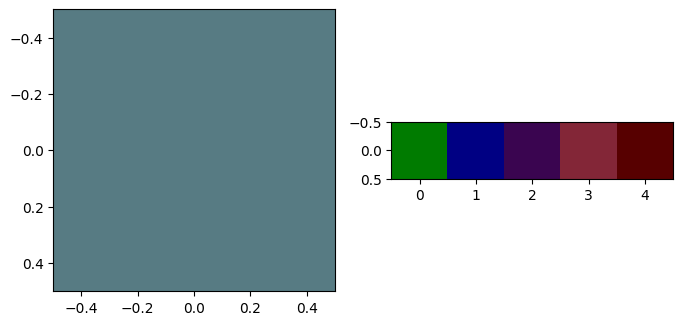

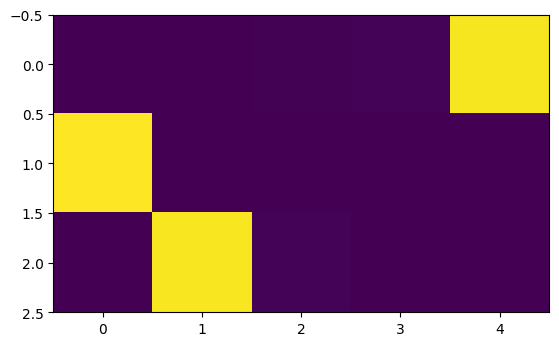

In [13]:
# Display the main color and the sequence
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(color1.unsqueeze(0))
ax[1].imshow(sequence.unsqueeze(0))
plt.show()


# showing the attention scores
out, attention_scores = mha(color1.unsqueeze(0), sequence.unsqueeze(0), return_score=True)

plt.imshow(attention_scores.detach().squeeze(0))
plt.show()

The attention scores show what we predicted. Each head is attending to one of the channels in the sequence and giving a higher score to the color that has the channel we are looking for. This shows how our model automatically learned to retrieved the relevant information from the training data.

We can now apply some improvements from this example. Since each head is attending to only one channel and filtering the others. We can use only one dimension for each head instead of three dimensions. This way we can reduce the number of parameters and make the model smaller (more efficient) while keeping the same performance:

In [14]:
class MHA(nn.Module):
    def __init__(self, heads=1, n_dim=1, beta=0.1):
        super(MHA, self).__init__()
        # instead of having n_dim * heads we can reduce the number of parameters by dividing n_dim / heads instead
        # this way each head will attend to a region of our embedding
        self.filter = nn.Linear(n_dim, n_dim)
        self.heads = heads
        self.head_dim = heads // n_dim
        self.n_dim = n_dim
        self.beta = beta

    def forward(self, x, y, return_score=False):
        query = self.filter(x)

        # here the query and keys embeddings are divided by number of heads
        split_query = torch.unflatten(query, 2, (-1, self.head_dim))
        split_keys = torch.unflatten(y, 2, (-1, self.head_dim))

        split_query = split_query.permute(0, 2, 1, 3)
        split_keys = split_keys.permute(0, 2, 1, 3)

        attention_score = 1 / (torch.sum(torch.pow(split_query - split_keys, 2), dim=-1) + self.beta)

        attention_score = torch.softmax(attention_score, dim=-1)

        split_values = y.unsqueeze(1)

        out = attention_score.unsqueeze(-1) * split_values
        head_sum = torch.sum(out, dim=-2)
        sequence_sum = torch.sum(head_sum, dim=1, keepdim=True)

        if return_score:
            return sequence_sum, attention_score
        else:
            return sequence_sum

Let's train again to check if we are losing performance by reducing the head size.

  0%|          | 0/60000 [00:00<?, ?it/s]

0.005257751829626542


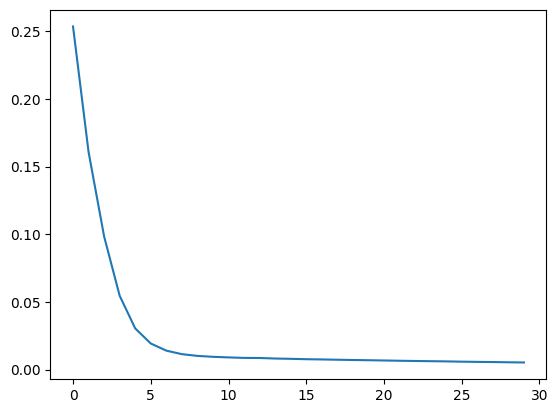

In [15]:
mha = mha = MHA(heads=3, n_dim=3)
lh = train(mha, dataset, epochs=30, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

Original color:
 tensor([[0.3440, 0.4837, 0.5160]])
Reconstructed color:
 tensor([[[0.3720, 0.4869, 0.5325]]], grad_fn=<SumBackward1>)


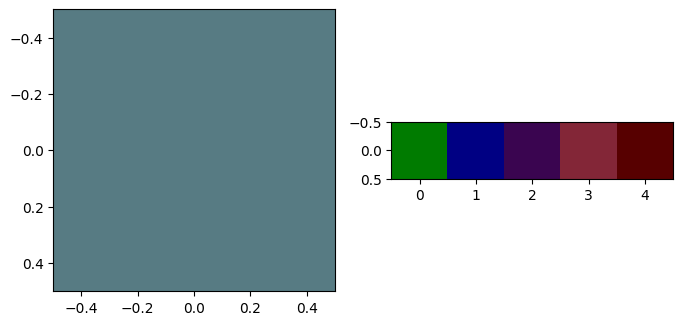

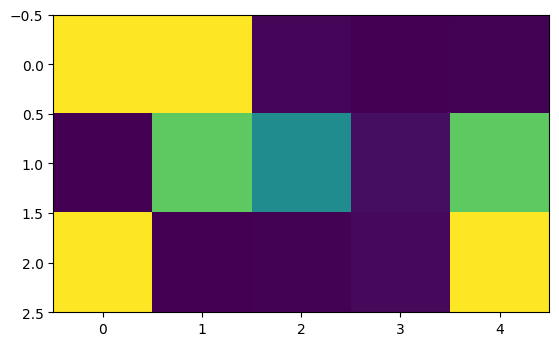

In [16]:
color1, sequence = dataset[0]

print('Original color:\n', color1)
print('Reconstructed color:\n', mha(color1.unsqueeze(0), sequence.unsqueeze(0)))

# Display the main color and the sequence
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(color1.unsqueeze(0))
ax[1].imshow(sequence.unsqueeze(0))
plt.show()


# showing the attention scores
out, attention_scores = mha(color1.unsqueeze(0), sequence.unsqueeze(0), return_score=True)

plt.imshow(attention_scores.detach().squeeze(0))
plt.show()

The performance is similar and the attention scores shows a similar behavior, but now it is more spread over the channels. This is because we are using only one dimension for each head, so the attention scores are not as sharp as before. However, the model is still able to learn to attend to the correct channels and reconstruct the original color.

## Computing memory and current state from previous tokens

Since our attention mechanism is able to retrieve relevant information from a sequence in parallel, we can use it to replace the recurrent nature of the LSTM from the previous chapter. Instead of maintaining a hidden state and memory embeddings that are updated iteratively for each new token, we can compute the memory and current state on the fly for each new token taking advantage of parallel computations.

To see how this works, lets build another toy example. In this example the model needs to predict the current state of a token based on relevant information from previous tokens in sequences with different lengths. The sequence starts with a start token 'S' and ends with an end token 'E'. In between we have a random sequence of characters from 'a' to 'd' and two special tokens 'X' and 'Y' that are the relevant information for our prediction. Our end token have 4 possible states based on the combination of the two special tokens 'X' and 'Y' previous in the sequence.

Let's built the dataset for this problem and train a model to solve it. First we need to create our vocabulary and the corresponding token indices to encode our sequences:


In [17]:
wi = {
    # start token 'S'
    'S': 0,
    # noise tokens [a, b, c, d]
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    # signal tokens [X, Y]
    'X': 5,
    'Y': 6,
    # end token 'E'
    'E': 7
}

Now we can generate the sentences. First we start with the start token then we generate a random sequence of characters from 'a' to 'd' with a random length. Then we add the two special tokens 'X' and 'Y' in random positions in the sequence. Finally, we add the end token 'E'. Each combination of the two special tokens 'X' and 'Y' gives us a different state for the end token 'E', this gives an example of how the attention can be used for the text modeling task.

In [18]:
import random

def gen_seq(max_len=10):
    # Start token
    final_sequence = ['S']

    # fill our sequence with at lest 4 tokens
    for _ in range(random.randint(4, max_len)):
        final_sequence.append(random.choice('abcd'))

    # first and second tokens positions
    token_pos1 = random.randint(1, len(final_sequence) - 2)
    token_pos2 = random.randint(token_pos1, len(final_sequence) - 1)

    # relevant tokens
    token1 = random.choice('XY')
    token2 = random.choice('XY')

    final_sequence[token_pos1] = token1
    final_sequence[token_pos2] = token2

    final_sequence.append('E')

    # each combination create a different state
    states = {
        'XX': 0,
        'XY': 1,
        'YX': 2,
        'YY': 3
    }
    return ''.join(final_sequence), states[token1 + token2]


sequence, state = gen_seq()
print(sequence, state)

SXadXcdE 0


Now we can apply our multi head attention to this problem. But here we have some modifications to make. In our color example, the query was the main color and the keys and values were the colors in the sequence. But in our state prediction problem the query is the token E that is inside the same sequence we are searching for. The attention where the query, keys, and values attend to the same initial sequence is called self attention. Since we are attending to the same sequence, we need also apply different transformations for the queries, keys, and values. Without these transformations, our attention matrix will be near to the identity matrix as each token is similar to itself.

Another modification is that the tokens are now embeddings and we can apply the dot product similarity instead of the distance formula. From the dot product formula

$$ \vec{a} \cdot \vec{b} = |\vec{a}| |\vec{b}| \cos(\theta) $$

we can see that we are computing the cosine of the angle between the vectors. If they point to the same direction this angle is near 0 and cosine of 0 is 1. However, to get the cosine of the angle we need to divide by the products of the norms of the vectors. Since computing norms require square roots that is an expensive operation, we can approximate it by dividing by the square root of the dimension of the vectors. This is called dot product attention. The last step is that instead of adding the head chanels together we will concatenate them and to mix the information in all heads we apply a final linear transformation. Putting everything together we have the following MHA class:

In [19]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        # query, key, and value transformations
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        # output transformation to mix the concatenated heads
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, return_scores=False):
        query = self.q(x)
        key = self.k(x)

        # split heads
        query = query.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        key = key.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        # dot product attention
        # we also need to transpose the keys for matrix multiplication
        attention = query @ key.permute(0, 1, 3, 2)

        # scale our attention weights to approximate the normalization
        attention /= math.sqrt(self.n_dim)

        attention = torch.softmax(attention, dim=-1)

        value = self.v(x)
        value = value.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        # weighted sum of values based on the attention scores
        output = attention @ value

        # reordering the head dimensions
        output = output.permute(0, 2, 1, 3)
        # concatenating the heads
        output = output.flatten(2)

        if return_scores:
            return self.o(output), attention
        else:
            return self.o(output)

Now we can test our MHA class to check if it is working as expected. However, our implementation have a problem. Since the final output is a weighted sum of the value tokens, the order of the tokens doesn't change the results as we can see in this test:

In [20]:
vocab_size = len(wi)
n_dim = 4

embedding_layer = nn.Embedding(vocab_size, n_dim)
mha = MHA(n_dim=n_dim, heads=2)

# Here we have the sme sequences but the X and Y positions are swapped
sequence1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
sequence2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

x1 = embedding_layer(sequence1).unsqueeze(0)
x2 = embedding_layer(sequence2).unsqueeze(0)

o1 = mha(x1)
o2 = mha(x2)

# comparing the final embeddings of the last token in both sequences
print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(True)


With our current implementation the final output is the same for both sequences since the attention scores are indifferent to position. In this case, our model won't be able to differ between XY and YX combinations. It is acting now as an attention over a set of elements. To solve this problem we need to inject positional information somehow to our model. One way to do this is adding the position of the token to the token embedding. This way, each token will have a different representation based on its position in the sentence. The simplest positional encoding is just adding the position index to the token embedding in all dimensions. One example, can be seen below:

In [21]:
sequence1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
positional_encoding = torch.arange(1, sequence1.shape[0]).unsqueeze(0)
# repeat for each dimension
positional_encoding = positional_encoding.repeat(n_dim, 1)
print(positional_encoding)

tensor([[1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6]])


We saw in the deep learning chapter that increasing the magnitude of our embeddings makes harder to our neural network to model the data. And since we are adding the position index to the token embedding, token embeddings in longer sentences will also have higher magnitudes making it harder to our attention model. Normalizing the positions won't solve this problem since we will have different position encodings when the sentence lenght changes. Instead of adding the position index direclty we can simple use the binary encoding of the position index. This way each dimension will have a maximun value of 1 and we will distribute the encoding of the position over the dimensions. Let's see how this works:

In [22]:
def binary(x, bits):
    mask = 2 ** torch.arange(bits - 1, -1, -1).to(x.device, x.dtype)
    return x.unsqueeze(-1).bitwise_and(mask).ne(0).float()


x1 = embedding_layer(sequence1).unsqueeze(0)

# computing the binary encodings for each token position
binary_encoding = binary(torch.arange(1, x1.shape[1] + 1), n_dim)
print(binary_encoding)

# adding the position encoding in the token embeddings
enc = x1 + binary_encoding

tensor([[0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 0., 1., 1.],
        [0., 1., 0., 0.],
        [0., 1., 0., 1.],
        [0., 1., 1., 0.],
        [0., 1., 1., 1.]])


Now we can test again with the positional encoding to check if our model is able to differ between the two sequences:

In [23]:
vocab_size = len(wi)
n_dim = 4

embedding_layer = nn.Embedding(vocab_size, n_dim)
mha = MHA(n_dim=n_dim, heads=2)

sequence1 = torch.LongTensor([wi[c] for c in 'SaXbYcE'])
sequence2 = torch.LongTensor([wi[c] for c in 'SaYbXcE'])

x1 = embedding_layer(sequence1).unsqueeze(0)
x2 = embedding_layer(sequence2).unsqueeze(0)

# adding positional information to the token embeddings
binary_encoding = binary(torch.arange(1, x1.shape[1] + 1), n_dim)

x1 += binary_encoding
x2 += binary_encoding

o1 = mha(x1)
o2 = mha(x2)

print(torch.isclose(o1[:, -1], o2[:, -1]).all())

tensor(False)


With the positional encoding now we have different representations for each sequence and our attention scores will be different depending on the position of the tokens. Now we can build a dataset to train our model.

To train our model efficiently with batches we need them to have the same size. But since our sequences have different lengths we need to pad them with a special token to make them all the same size. Also, we need to ignore them in the attention scores since they are not part of the original sequence. To do this we can add a padding token to our vocabulary and assign use it to pad our sequences. Next we need to modify our attention scores to ignore the padding tokens by using a mask to filter the tokens we don't want to consider. Let's start by creating our dataset:

In [24]:
# adding the padding token
# we will use '-' as a padding
# but can be any other token that is not being used in the data
wi['-'] = 8

In [25]:
def build_sequence_dataset(n):
    sequences = []
    labels = []
    for _ in range(n):
        s, q = gen_seq()
        sequences.append(s)
        labels.append(q)

    # tokenize the sequences
    seqs = [[wi[c] for c in s] for s in sequences]

    # max len for padding
    max_len = max([len(s) for s in seqs])

    # the index of the last tokens for batch selecting before padding
    last_token_position = torch.LongTensor([len(s) - 1 for s in seqs])

    # mask to ignore padding in the attention
    # 1 = filter this token
    attention_mask = torch.BoolTensor([[0] * len(s) + [1] * (max_len - len(s)) for s in seqs])

    # we concatenate the padding tokens until the sequence gets the maximum length
    seqs = [q + [wi['-']] * (max_len - len(q)) for q in seqs]

    return TensorDataset(torch.LongTensor(seqs), attention_mask, last_token_position, torch.LongTensor(labels))


dataset = build_sequence_dataset(500)

We also need to modify our MHA class to ignore the padding tokens in the attention scores by using a mask. Since our attention scores are computed using the softmax function, we can use a trick to filter the values in parallel. Here is the formula of the softmax function:

$$ \text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}} $$

Because the softmax is computed using exponential, and the exponential of a very large negative number is near to zero (exponent of a negative number is a division), we can set the attention scores of the padding tokens to a very large negative number to make their softmax values near to zero. This way, we are effectively ignoring the padding tokens in the attention scores.

In [26]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, padding_mask=None, return_scores=False):
        query = self.q(x)
        key = self.k(x)

        query = query.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        key = key.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        attention = query @ key.permute(0, 1, 3, 2)
        attention /= math.sqrt(self.n_dim)

        # filtering the padding tokens
        if padding_mask is not None:
            attention = torch.masked_fill(attention, padding_mask.unsqueeze(1).unsqueeze(1), -1e6)

        attention = torch.softmax(attention, dim=-1)

        value = self.v(x)
        value = value.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        output = attention @ value

        output = output.permute(0, 2, 1, 3)
        output = output.flatten(2)

        if return_scores:
            return self.o(output), attention
        else:
            return self.o(output)

Now we can pack all layers in a model and start the training.

In [27]:
class Model(nn.Module):
    def __init__(self, vocab_size, states, n_dim=16, n_head=4):
        super(Model, self).__init__()

        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        
        # number of states
        self.lm = nn.Sequential(
            nn.Linear(n_dim, states),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

    def forward(self, x, padding_mask=None):
        pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
        # adding positional encoding to the token embeddings
        e = self.emb(x) + pos
        # computing the new token embedding attending to the other tokens in the sequence
        mha = self.mha(e, padding_mask=padding_mask)
        return self.lm(mha)

Then we need just to implement our training function.

  0%|          | 0/50000 [00:00<?, ?it/s]

0.4840616565197706


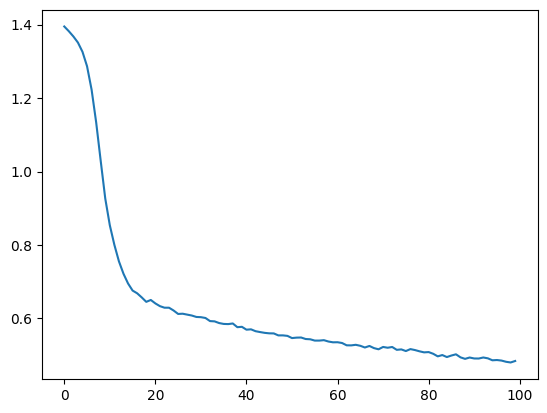

In [28]:
def train_model(model, data, epochs=10, lr=0.001, batch_size=16):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()
    progress = tqdm(total=len(data) * epochs)
    lh = []
    for epoch in range(epochs):
        el = []
        for (x, am, em, y) in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, padding_mask=am)
            # the loss is computed using only the last token 'E'
            loss = crit(out[torch.arange(x.shape[0]), em], y)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    return lh


model = Model(vocab_size=9, states=4, n_dim=8, n_head=2)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
print(lh[-1])
plt.plot(lh)
plt.show()

Our model is learning well as we can see by the training loss. We can now check the predictions of our model to see if it is able to differ between the two sequences and predict the correct state for the end token 'E' based on the combination of the two special tokens 'X' and 'Y' in the sequence.

In [29]:
sequence1 = torch.LongTensor([[wi[c] for c in 'SaXbYcE']])
sequence2 = torch.LongTensor([[wi[c] for c in 'SaYbXcE']])

model.eval()

with torch.no_grad():
    o1 = model(sequence1)
    o2 = model(sequence2)

# the states index
answers = {
    'XX': 0,
    'XY': 1,
    'YX': 2,
    'YY': 3
}

print(o1[:, -1].argmax())
print(o2[:, -1].argmax())


tensor(1)
tensor(2)


Now we can see the attention scores to check how our model is attending to the tokens in the sequence. Since we have two heads in this example, we will have two attention scores for each sequence. We can plot them to see what tokens the model is looking at to compute the state for the token 'E'.

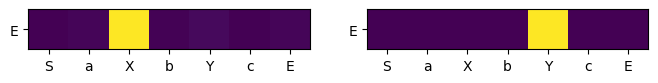

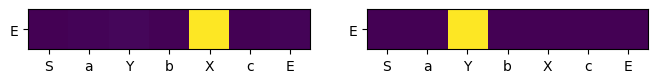

In [30]:
def plot_attention(attention, sequence):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    ax[0].imshow(attention[0, -1, :].unsqueeze(0))

    ax[0].set_xticks(range(len(sequence)))
    ax[0].set_xticklabels(sequence)
    ax[0].set_yticks([0])
    ax[0].set_yticklabels(['E'])
    ax[1].imshow(attention[1, -1, :].unsqueeze(0))
    ax[1].set_xticks(range(len(sequence)))
    ax[1].set_xticklabels(sequence)
    ax[1].set_yticks([0])
    ax[1].set_yticklabels(['E'])
    plt.show()

sequence1 = 'SaXbYcE'
sequence2 = 'SaYbXcE'

x1 = torch.LongTensor([[wi[c] for c in sequence1]])
x2 = torch.LongTensor([[wi[c] for c in sequence2]])

position_encoding = binary(torch.arange(1, x1.shape[1] + 1), model.n_dim)

with torch.no_grad():
    e1 = model.emb(x1) + position_encoding
    output, a1 = model.mha(e1, return_scores=True)

    e2 = model.emb(x2) + position_encoding
    output, a2 = model.mha(e2, return_scores=True)

attention1 = a1.squeeze(0)
attention2 = a2.squeeze(0)

plot_attention(attention1, sequence1)
plot_attention(attention2, sequence2)


Looking at the attention scores we can see that the model learned to filter the noise tokens and focus only on the relevant tokens 'X' and 'Y'. The information each head attends change on each run but in all cases we can see that the relevant tokens are most of the time highlighted in the attention scores.

About the loss curve, we can see that it is not converging to 0. One of the causes is that our binary positional encoding gives a sharp change in the token embeddings when the position changes. Our gradient descent likes smooth changes in our weights to find the optimal solution. So if we find a smooth positional encoding it can help our model to converge better.

Let's plot each dimension of our positional embeddings to see how they look like:

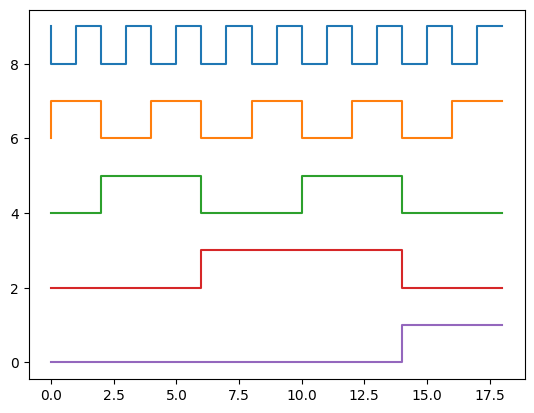

In [31]:
# base encoding
binary_encoding = binary(torch.arange(1, 20), 5)

# adding a constant in each dimension to plot the different dimensions in different lines
binary_encoding = binary_encoding + torch.arange(5).unsqueeze(0) * 2

for prompts in torch.flip(binary_encoding, dims=[1]).T:
    plt.step(torch.arange(prompts.shape[0]), prompts)
plt.show()

We can see that our positional encoding is similar to oscilating functions with different frequencies in each dimension. We can use this idea to create a smooth positional if we use oscilating functions like sine and cosine functions to encode the position of the tokens. We can also use decreasing frequencies for each dimension to have a similar behavior to our binary encoding where each set of dimensions encodes a different bit of the position index. The proposed formula for this positional encoding in the paper that introduced the transformer architecture is the following:

$$ PE(pos, 2i) = \sin(pos / 10000^{2i/d_{model}}) $$

$$ PE(pos, 2i+1) = \cos(pos / 10000^{2i/d_{model}}) $$

Where $pos$ is the position index and $i$ is the dimension index. Also, the base of the frequencies is 10000 that is a hyperparameter that can be tuned. With this positional encoding we have a smooth change in the token embeddings as the position changes, which can help our model to converge better. Let's implement this positional encoding and check how it looks like:

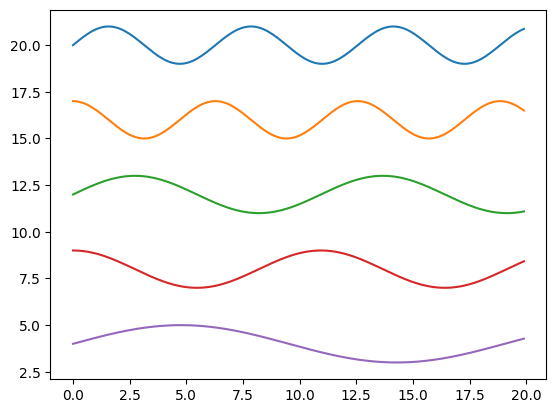

In [32]:
max_new_tokens = 20
n_dim = 5
base = 2

# our positions for the oscilating functions
sequence = torch.arange(0, max_new_tokens, 0.1)

for i in range(n_dim):

    if i % 2 == 0:
        text = sequence / (base ** (2 * i / n_dim))
        prompt_tensor = torch.sin(text)
    else:
        text = sequence / (base ** (2 * (i - 1) / n_dim))
        prompt_tensor = torch.cos(text)

    plt.plot(sequence, (5 - i) * 4 + prompt_tensor)
plt.show()

Our positional encoding is now smooth and we can see that each dimension has a different frequency. Also the frequencies are decreasing as the dimension index increases, which is similar to our binary encoding where each set of dimensions encodes a different bit of the position index. We can now put this into a function and use it in our model to see if it helps our model to converge better.

In [33]:
def pos_encode(max_len, d_model, base=10000.0):
    position = torch.arange(max_len).unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(base) / d_model))

    pe = torch.zeros(max_len, d_model)

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

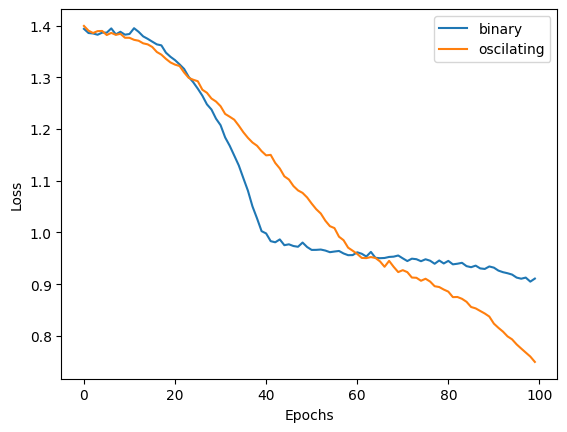

In [34]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, use_pos=True, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.mha = MHA(n_dim, n_head)
        self.lm = nn.Sequential(
            nn.Linear(n_dim, 4),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        # we can cache the positional encoding in a non trainable parameter since it is fixed and does not need to be updated during training
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)
        self.use_pos = use_pos

    def forward(self, x, padding_mask=None):
        # alternate between binary and oscilating positional encoding for comparison
        if self.use_pos:
            pos = self.pos[:x.shape[1], :]
        else:
            pos = binary(torch.arange(1, x.shape[1] + 1), self.n_dim)
            
        e = self.emb(x) + pos
        mha = self.mha(e, padding_mask=padding_mask)
        return self.lm(mha)


# binary positional encoding
model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=False)
# initializing all weights to the same value to make the comparison between the two positional encodings more clear
for param in model.parameters():
    nn.init.constant_(param, 0.5)
    
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh, label='binary')

# oscilating positional encoding
model = Model(vocab_size=9, n_dim=8, n_head=2, use_pos=True)
for param in model.parameters():
    nn.init.constant_(param, 0.5)
lh = train_model(model, dataset, epochs=100, lr=0.001, batch_size=32)
plt.plot(lh, label='oscilating')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


Not that the oscilating positional encoding is smoother and leads to a better convergence than the binary positional encoding as we can see in the loss curve. Some runs may show a more clear difference between the two positional encodings and in some cases the binary positional encoding may even plateau at a higher loss than the oscilating positional encoding. Smoother transition helps the model scape from local minima and find better solutions.

# Training the model to perform analytic tasks

We saw that our attention mechanism is able to retrieve relevant information from a sequence in parallel and that we can use it to replace the recurrent nature of the LSTM. Now, we can use this mechanism to teach our model to perform some analytic tasks by training the model to predict the next token in the sequence. For example, we can train our model to turn all characters in the sequence to uppercase. Our task will start with a start token 'S' then we have a random sequence of characters from 'a' to 'd' in lower or upper case and then we have a special token '^' to indicate that starting from here all the next tokens are the uppercase version of the previous characters. This is a simple task but it shows that, due to the attention mechanism, we can train our model to perform some logical tasks by just training it to predict the next token in the sequence. After, the '^' token, to correctly predict the next token, the model needs to find the correct token in the previous sequence and decide to output the uppercase version of it or just copy if its already in uppercase.

The LSTM is also able to learn this task but with the attention mechanism we can train the next token prediction in parallel. This is a powerful feature since we can just give a sequence of tokens in a task we want our model to learn and train it to predict the next token in that sequence.

For this example, lets add more tokens to our initial vocabulary to include the uppercase characters and the special token '^' and generate a dataset for this task. Then we can train our model to see if it is able to learn this task.

In [35]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    # uppercase characters
    'A': 5,
    'B': 6,
    'C': 7,
    'D': 8,
    'X': 9,
    'Y': 10,
    'E': 11,
    '-': 12,
    # special token to indicate what we want to do
    '^': 13
}

iw = {v: k for k, v in wi.items()}

Now we can generate a random sequence in the uppercase task and create our dataset. Note that we can't predict the tokens before the token '^' since they are supposed to be provided by the user. The part in the text provided by the user is called prompt. And since our model don't have access to whats inside the user mind we won't be able to predict those tokens. So we need to ignore them in the loss computation. For that we can use the same approach we used to ignore the padding tokens in the attention but instead of filtering them in the attention scores we will filter in the loss computation. We can create a mask of ones for the tokens we want to consider and zeros for the tokens we want to ignore and multiply the loss by this mask to ignore the tokens in the loss computation. Everything multiplyed by zero will have a zero gradient that won't impact our weight updates.

Now we can update our dataset generation function.

In [36]:
def gen_up_seq(max_len=15):
    r = ''
    for _ in range(random.randint(1, (max_len - 3) // 2)):
        r += random.choice('abcdABCD')

    return f'S{r}^{r.upper()}E'


def gen_up_data(n, max_len=15, tokenize=True):
    tokenized_sequences = []
    for _ in range(n):
        s = gen_up_seq(max_len)
        tokenized_sequences.append(s)

    if not tokenize:
        return tokenized_sequences

    # mask to ignore the prompt part in the loss
    prompt_mask = [[0] * s.index('^') + [1] * (len(s) - s.index('^') - 1) + [1] for s in tokenized_sequences]
    
    tokenized_sequences = [[wi[c] for c in s] for s in tokenized_sequences]
    
    seq_max_len = max([len(s) for s in tokenized_sequences])
    
    # attention mask to ignore the padding tokens in the attention
    attention_mask = [[0] * len(s) + [1] * (seq_max_len - len(s)) for s in tokenized_sequences]
    # padding the sequences and prompt mask to the maximum length
    prompt_mask = [s + [0] * (seq_max_len - len(s)) for s in prompt_mask]
    tokenized_sequences = [q + [wi['-']] * (seq_max_len - len(q)) for q in tokenized_sequences]
    
    return TensorDataset(torch.LongTensor(tokenized_sequences), torch.Tensor(attention_mask), torch.Tensor(prompt_mask))

max_new_tokens = 20
n_train = 1000
n_test = 50

data = gen_up_data(n_train, max_new_tokens)
# we don't tokenize the test data here since it will be tokenized in the evaluation function
test = gen_up_data(n_test, max_new_tokens, tokenize=False)

Let's see one sample of our dataset:

In [37]:
sequence, attention_mask, prompt_mask = data[0]

# decoded sequence
print([iw[q.item()] for q in sequence])

print(sequence)
print(attention_mask)
print(prompt_mask)

['S', 'a', 'b', 'c', 'c', '^', 'A', 'B', 'C', 'C', 'E', '-', '-', '-', '-', '-', '-', '-', '-']
tensor([ 0,  1,  2,  3,  3, 13,  5,  6,  7,  7, 11, 12, 12, 12, 12, 12, 12, 12,
        12])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
        1.])
tensor([0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0.])


Note how the attention mask have zeros at the positions of the relevant tokens and ones at the positions of the padding tokens. And, the loss mask ignores the padding tokens and the prompt tokens.

To train our model in next token prediction in parallel, we need to modify our attention mechanism. In our current implementation, the attention scores are computed by leeting all tokens attending to each other. However, for example, the first token can only attend to itself since the other tokens are not available yet. We need to mask also the attention of future tokens to prevent the model from attending to tokens that are not generated. This is the point where we are improving the efficiency compared to the LSTM. Since we will mask the information from future tokens, this is equivalent to training to predict each next token in parallel.

This is called causal mask and we can implement it by adding a upper triangular filter to the attention scores. This way, each token will only attend to itself and previous tokens.

In [38]:
class MHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(MHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, padding_mask=None, return_scores=False):
        query = self.q(x)
        key = self.k(x)

        query = query.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        key = key.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        attention = query @ key.permute(0, 1, 3, 2)
        attention /= math.sqrt(self.n_dim)

        # creating a causal mask to prevent the model from attending to future tokens
        causal_mask = torch.triu(torch.ones(attention.shape[-2:], device=attention.device), diagonal=1).bool()
        
        if padding_mask is not None:
            padding_mask = padding_mask.unsqueeze(1).unsqueeze(1).bool()
            # combining the padding mask and the causal mask  
            attention_mask = torch.logical_or(padding_mask, causal_mask)
        else:
            attention_mask = causal_mask
            
        attention = torch.masked_fill(attention, attention_mask, -1e6)
        
        attention = torch.softmax(attention, dim=-1)

        value = self.v(x)
        value = value.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        output = attention @ value

        output = output.permute(0, 2, 1, 3)
        output = output.flatten(2)

        if return_scores:
            return self.o(output), attention
        else:
            return self.o(output)

Now we can update our model and training function to include the prompt masks.

In [39]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        # using updated MHA with causal masking
        self.mha = MHA(n_dim, n_head)

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim
        self.pos = nn.Parameter(pos_encode(max_len, n_dim, base=2), requires_grad=False)

    def forward(self, x, m=None):
        pos = self.pos[:x.shape[1], :]
        e = self.emb(x) + pos
        e = self.mha(e, m)
        return self.lm(e)

Also, its very important to evaluate our model while it is training to check if it is learning the task as expected. We can check the predictions of our model in the test dataset and to help with this we can write generate function in our model. The generation function is similar to the text generation function we implemented in the LSTM chapter.

We can also generate multiple sequences in parallel by giving a list of prompts to the generation function. However, we need to note an important detail in the generation process. Since we need to generate the next token of sequences with different sizes we still need to add padding tokens to generate them in parallel. However, since the next token will be placed at the right part of the sequence, we can't add the padding tokens to the right of the sequence as we did in the training data. We need to add the padding on the left of the sequence to make sure that the current token is always at the right part of the sequence. The position of the padding doesn't affect the attention scores since they are discarded by the attention mask.

In [40]:
# the generation function will be used to generate new sequences given a list of prompts
def gen(self, prompts, max_new_tokens=10, batch_size=16):
    self.eval()

    # first computing the maximum length of the sequences
    seq_max_len = max([len(q) for q in prompts])
    
    # start with zeros since we are left padding
    attention_mask = [[0] * len(q) for q in prompts]
    
    # adding the padding tokens to the left of the sequences
    prompts = ['-' * (seq_max_len - len(q)) + q for q in prompts]
    # tokenizing the prompts
    prompts = [[wi[q] for q in w] for w in prompts]
    # adding the padding tokens to the attention mask
    attention_mask = [[1] * (seq_max_len - len(q)) + q for q in attention_mask]

    prompt_tensor = torch.LongTensor(prompts)
    attention_mask = torch.Tensor(attention_mask)

    output = []
    # batch generation to limit max memory usage without shuffling to keep the same order of the prompts
    for x, m in DataLoader(TensorDataset(prompt_tensor, attention_mask), batch_size=batch_size, shuffle=False):
        
        # generate new tokens untill the maximun length is reached
        for _ in range(max_new_tokens):
            
            # we don't need gradients since we are not training
            with torch.no_grad():
                o = self(x, m)
                
                # sampling the most probable token and adding it to the sequence
                new_token = o.exp().argmax(dim=-1)[:, -1].unsqueeze(1)
                # update the input and the attention mask for the next iteration
                x = torch.cat([x, new_token], dim=1)
                m = torch.cat([m, torch.zeros(m.shape[0], 1)], dim=1)
                
        output.append(x)

    final_result = torch.cat(output, dim=0)
    # decoding the output sequences back to text
    decoded_output = []
    for q in final_result:
        decoded_output.append(''.join([iw[c] for c in q.tolist()]))

    return decoded_output

Model.gen = gen

Now we need to write our evaluation function to check the performance of our model while it is training. We will give only the prompts to our model and ask it to predict the correct completion. Then we compare it with the correct answer to check how well our model is going. In this case we will check both the number of correct characters in the correct position and the number of 100% correect sentences.

In [41]:
def test_model(model, test, max_new_tokens=10):
    prompts = []
    answers = []
    for t in test:
        q1, q2 = t.split('^')
        prompts.append(q1 + '^')
        answers.append(q2)

    # generating the sequences given the prompts
    output = model.gen(prompts, max_new_tokens=max_new_tokens)
    
    correct_token_count = []
    correct_sequence_count = []
    
    for out, answer in zip(output, answers):
        sequence_output = out.split('^')[-1].split('E')[0] + 'E'
        
        # we need to pad the output and the answer to the same length to compare them token by token
        max_len = max(len(sequence_output), len(answer))

        p1 = sequence_output + '-' * (max_len - len(sequence_output))
        p2 = answer + '-' * (max_len - len(answer))
        
        # 1 if the token is correct and 0 if it is not
        correct = [1 if q == w else 0 for q, w in zip(p1, p2)]
        correct_token_count.extend(correct)
        # if all the tokens are correct then the sequence is correct
        correct_sequence_count.append(1 if sum(correct) == len(correct) else 0)

    return sum(correct_token_count) / len(correct_token_count), sum(correct_sequence_count) / len(correct_sequence_count)

Then we can update our training function to include the evaluation of our model while it is training. We can check the performance every few epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

0.02452990785241127


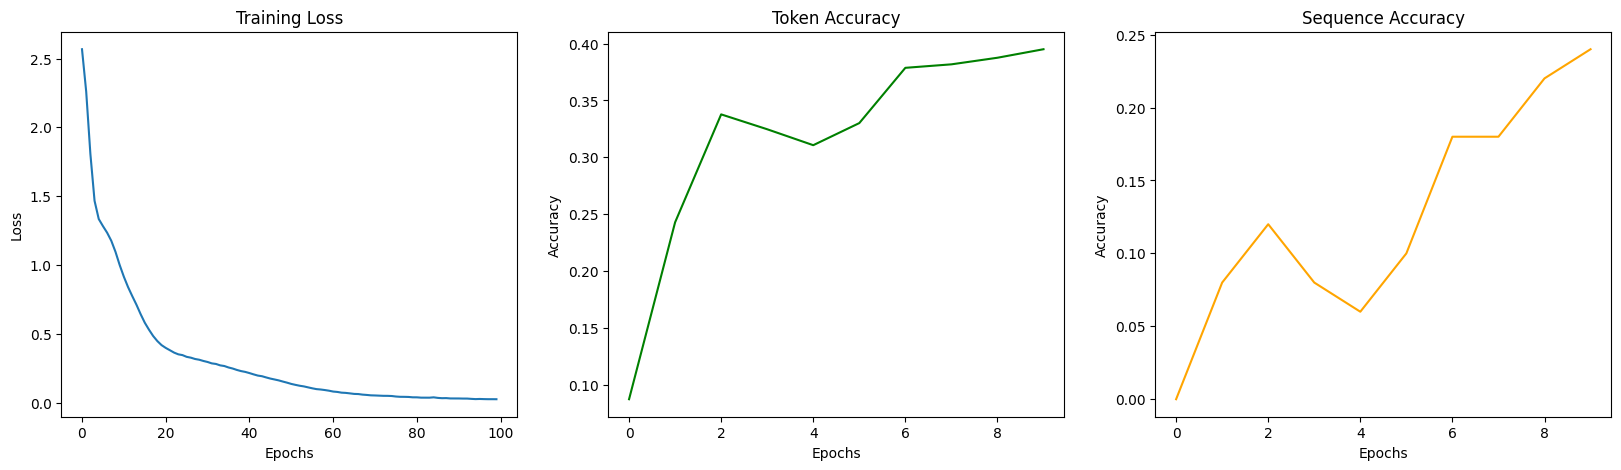

In [42]:
def lm_train(model, data_train, data_test=None, epochs=100, lr=0.001, batch_size=32, test_every=10, max_new_tokens=20):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss(reduction='none')
    progress = tqdm(total=len(data_train) * epochs)
    lh = []
    tl = []
    for epoch in range(epochs):
        model.train()
        el = []
        for (x, m, lm) in DataLoader(data_train, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            out = model(x, m)
            loss = crit(torch.flatten(out[:, :-1], start_dim=0, end_dim=1), x[:, 1:].flatten())
            
            # we need to ignore the loss for the prompt tokens and the padding tokens
            loss = torch.sum(loss * lm[:, :-1].flatten()) / torch.sum(lm[:, :-1])

            loss.backward()
            el.append(loss.item())
            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))
        
        # testing the model every test_every epochs and appending the results to tl
        if data_test is not None and epoch % test_every == 0:
            tl.append(test_model(model, data_test, max_new_tokens=max_new_tokens))
    progress.close()
    return lh, tl


model = Model(vocab_size=len(wi), n_dim=32, n_head=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_new_tokens=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
l1, l2 = zip(*tl)
ax[1].plot(l1, c='green')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Token Accuracy')

ax[2].plot(l2, c='orange')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Accuracy')
ax[2].set_title('Sequence Accuracy')
plt.show()

Our model is converging and learning well. However, looking at the test we can see that is not having a good performance. This problem comes from the tokenization we are using in the generation part. Since our positional encoding is absolute and gives one encoding to each position in the sequence, when we pad our sequences in the generation part, we are changing the position of the start tokens causing a bias problem in our model. In the training dataset, the start token is always at the first position, and receives always the same position encoding. But in the generation part that is used in test, the sequencies are being padded on the left, changing the position of the start token to a position that was never seen in the training data. Even that the padding tokens are ignored in the attention scores, the position encoding of the tokens are mixed in the token embeddings and the model is not able to generalize.

To solve this problem we need to use a positional encoding that consider the relative distance between tokens instead of the absolute position. This way even if the sentence starts at different positions the relative distance between tokens are the same.

## Relative positional encoding

The use of absolute positional encoding is causing generalization problems in our model. To solve this problem we need to make the attention mechanism aware of the order of the tokens while insensitive to its absolute position. One way to solve this is taking benefit of how our attention scores are computed. Since our scores are computed with the dot product between two vectors and the dot product computes the cosine of the angle between the vectors, as long as the angle between the vectors is the same, it doesn't matter their absolute position in the sequence. Also, since the position information is only needed in the attention computation, we need to change then only at the attention computation instead of adding the positional encoding to the token embeddings.

In the absolute positional encoding, we add the positional encoding with the token embeddings with different frequencies for each dimension. Instead of this addition, we can rotate our queries and keys by an angle based on their position in the sequence and by computing the dot product between we will get the relative angle between them. This way we are also encoding the relative position between tokens without changing the value embeddings and token embeddings.

Since our vectors are n-dimensional, applying a rotation in n-dimensions is not trivial as it requires a rotation over a hypersphere that requires increasing multiplications of sine and cosine functions with is inneficient. Instead of this, we can split our vector dimensions in pairs analogouts to how we split into multiple heads and apply a 2D rotation with different angles in each pair of dimensions, as in our previous encoding, wich is easier to compute. The model can also infer the absolute position by comparing the relative position to the start token position if needed. This technique is called Rotary Positional Encoding or RoPE for short.

First let's implement the rotation function. First we split the last embedding dimension in pairs to apply the 2D rotation. For this we only need the input vector and the frequencies for each pair of dimensions. Then we rotate the vectors and concatenate back the rotate dimensions:

$$ R\mathbf{v}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
x\cos\theta - y\sin\theta \\
x\sin\theta + y\cos\theta
\end{bmatrix}. $$

In [43]:
def apply_rope(vec, freq):
    # we split the last dimension into pairs of dimensions to apply the rotation on each pair
    split_pairs = vec.unflatten(-1, (-1, 2))
    
    # adapting the frequency shape to be broadcastable with the split pairs
    theta = freq.unsqueeze(1).unsqueeze(-1)
    theta = theta[:, :, :split_pairs.shape[2], :]

    x = split_pairs[:, :, :, :, 0]
    y = split_pairs[:, :, :, :, 1]
    
    # rotation
    nx = x * torch.cos(theta) - y * torch.sin(theta)
    ny = x * torch.sin(theta) + y * torch.cos(theta)

    # combining the rotated pairs back to the original shape
    rotated_vec = torch.cat([nx.unsqueeze(-1), ny.unsqueeze(-1)], dim=-1)
    return rotated_vec.flatten(-2)

Now we need to add the rotations to the queries and keys in our attention computation.

In [44]:
class RMHA(nn.Module):
    def __init__(self, n_dim=16, heads=2):
        super(RMHA, self).__init__()
        self.q = nn.Linear(n_dim, n_dim, bias=False)
        self.k = nn.Linear(n_dim, n_dim, bias=False)
        self.v = nn.Linear(n_dim, n_dim, bias=False)
        self.o = nn.Linear(n_dim, n_dim, bias=False)

        self.n_dim = n_dim
        self.heads = heads
        self.head_dim = n_dim // heads

    def forward(self, x, freq=None, padding_mask=None, return_scores=False):
        query = self.q(x)
        key = self.k(x)

        query = query.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        key = key.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)
        
        # applying the RoPE to the query and key tensors
        if freq is not None:
            query = apply_rope(query, freq)
            key = apply_rope(key, freq)

        attention = query @ key.permute(0, 1, 3, 2)
        attention /= math.sqrt(self.n_dim)

        causal_mask = torch.triu(torch.ones(attention.shape[-2:], device=attention.device), diagonal=1).bool()
        
        if padding_mask is not None:
            padding_mask = padding_mask.unsqueeze(1).unsqueeze(1).bool()
            attention_mask = torch.logical_or(padding_mask, causal_mask)
        else:
            attention_mask = causal_mask
            
        attention = torch.masked_fill(attention, attention_mask, -1e6)
        
        attention = torch.softmax(attention, dim=-1)

        value = self.v(x)
        value = value.unflatten(2, (-1, self.head_dim)).permute(0, 2, 1, 3)

        output = attention @ value

        output = output.permute(0, 2, 1, 3)
        output = output.flatten(2)

        if return_scores:
            return self.o(output), attention
        else:
            return self.o(output)

Now we can build our model. First, we need to compute the frequencies for our RoPE encodings. We will use a similar approach of decreasing frequencies as in our previous positional encoding with the following formula:

$$ \text{freq} = \frac{1}{base^{2i/d_{model}}} $$

Also, to improve the model capacity we can stack multiple layers in the same way we stacked multiple LSTM layers in the previous chapter. Each layer will have its own set of parameters and will be able to learn different representations of the data. 

In [45]:
class Model(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20):
        super(Model, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        # multiple attention layers
        self.attention_layers = nn.ModuleList([RMHA(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        # precomputing the frequencies for the RoPE encoding based
        positions = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(20, 2 * freq_size / n_dim)

        self.frequencies = torch.flatten(positions.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, attention_mask=None):
        e = self.emb(x)
        for al in self.attention_layers:
            e = al(e, self.frequencies, attention_mask)
        return self.lm(e)

    
Model.gen = gen

  0%|          | 0/100000 [00:00<?, ?it/s]

0.08879840769805014


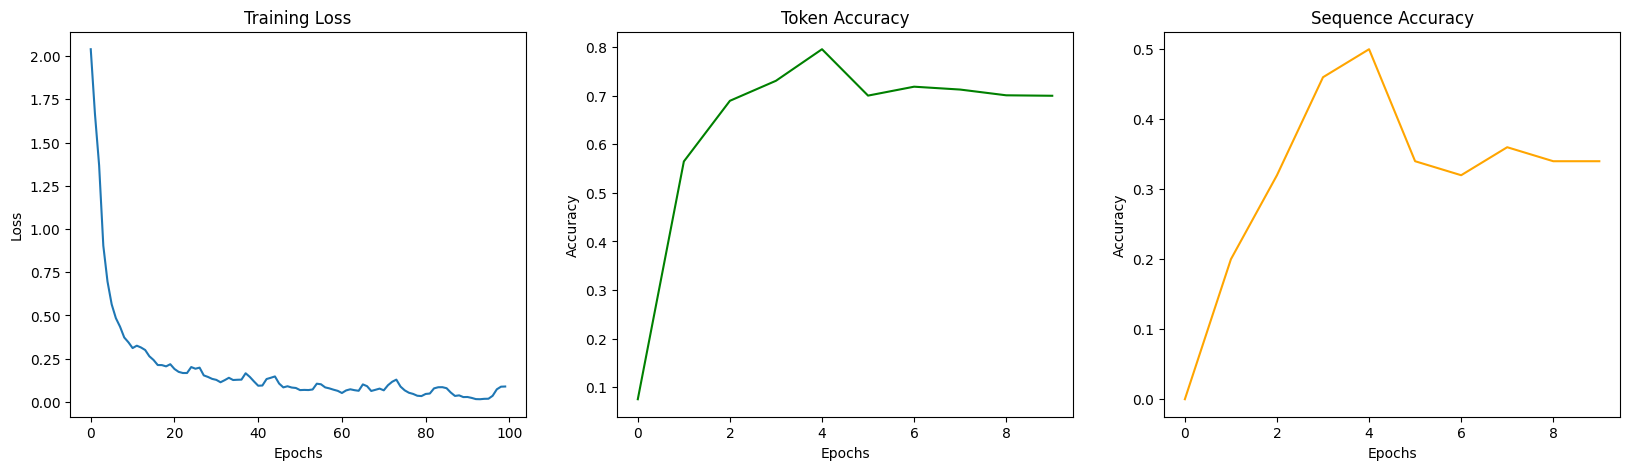

In [46]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=2, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_new_tokens=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

print(lh[-1])
ax[0].plot(lh)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
l1, l2 = zip(*tl)
ax[1].plot(l1, c='green')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Token Accuracy')

ax[2].plot(l2, c='orange')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Accuracy')
ax[2].set_title('Sequence Accuracy')
plt.show()

The relative positional encoding gives a great improvement in the performance of our model as we can in the tests. We can also test to see the model outputs:

In [47]:
prompts = ['Sabc^', 'SaABcd^', 'Sbbbb^']

outputs = model.gen(prompts, max_new_tokens=20)

print([x.split('E')[0] for x in outputs])

['--Sabc^ABC', 'SaABcd^AABCD', '-Sbbbb^BBBB']


And the model is able to uppercase the characters in the sequence as expected. We can further improve it but let's include more complex tasks first.

## Transformers are multitask learners

Given that our model is able to know to upercase the characters given the token '^', we can also train it to perform other tasks if we give other tokens. For example, we can train in multiple tasks at the same time such as lowercasing the characters or reversing the string.

Before the adoption of attention mechanisms in language models most of the models were trained to perform a single specific task such as classification, translation, etc. Being able to perform multiple tasks with the same model is the main requirement to achieve what is called artificial general intelligence (AGI). And with the attention mechanism the model can infer what task to perform given the context in the prompt.

Let's add three more tasks to our dataset: lowercasing the characters with the token 'v', reversing the string with the token '<' and copying with the token '='. We can generate the dataset with all those tasks mixed and check how our model is performing.

Let's start by adding the new tokens to our vocabulary and updating our dataset generation function to include the new tasks.

In [48]:
wi = {
    'S': 0,
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'A': 5,
    'B': 6,
    'C': 7,
    'D': 8,
    'X': 9,
    'Y': 10,
    'E': 11,
    '-': 12,
    '^': 13,
    # new tokens for lowercasing, reverse, and copy operations
    'v': 14,
    '<': 15,
    '=': 16
}

iw = {v: k for k, v in wi.items()}

In [49]:
def gen_tasks_seq(n=15):
    r = ''
    for _ in range(random.randint(1, (n - 3) // 2)):
        r += random.choice('abcdABCD')

    t = random.randint(0, 3)

    if t == 0:
        return f'S{r}^{r.upper()}E', '^'
    elif t == 1:
        return f'S{r}v{r.lower()}E', 'v'
    elif t == 2:
        rs = ''.join(reversed(r))
        return f'S{r}<{rs}E', '<'
    elif t == 3:
        return f'S{r}={r}E', '='

    return None, None

def gen_tasks_data(n, max_len=15, tokenize=True):
    sequences = []
    task_tokens = []
    for _ in range(n):
        s, k = gen_tasks_seq(max_len)
        sequences.append(s)
        task_tokens.append(k)

    if not tokenize:
        return sequences, task_tokens

    # we need the task token to create the prompt mask 
    prompt_mask = [[0] * s.index(k) + [1] * (len(s) - s.index(k) - 1) + [1] for s, k in zip(sequences, task_tokens)]
    sequences = [[wi[c] for c in s] for s in sequences]

    seq_max_len = max([len(s) for s in sequences])
    attention_mask = [[0] * len(s) + [1] * (seq_max_len - len(s)) for s in sequences]
    prompt_mask = [s + [0] * (seq_max_len - len(s)) for s in prompt_mask]
    sequences = [q + [wi['-']] * (seq_max_len - len(q)) for q in sequences]
    return TensorDataset(torch.LongTensor(sequences), torch.Tensor(attention_mask), torch.Tensor(prompt_mask))


data = gen_tasks_data(2000, 20)
test = gen_tasks_data(50, 20, tokenize=False)

We update also our evaluation function to check the performance of our model in all tasks. We can also check the performance in each task separately to see if there is any task that is harder for our model to learn.

In [50]:
def test_model(model, test, max_new_tokens=10):
    prompts = []
    answers = []
    tasks = []
    for t, task in zip(*test):
        q1, q2 = t.split(task)
        prompts.append(q1 + task)
        answers.append(q2)
        tasks.append(task)

    o = model.gen(prompts, max_new_tokens=max_new_tokens)
    
    correct_tokens = {t: [] for t in set(tasks)}
    correct_sentences = {t: [] for t in set(tasks)}
    for out, answer, task in zip(o, answers, tasks):
        so = out.split(task)[-1].split('E')[0] + 'E'
        ml = max(len(so), len(answer))

        p1 = so + '-' * (ml - len(so))
        p2 = answer + '-' * (ml - len(answer))

        m = [1 if q == w else 0 for q, w in zip(p1, p2)]
        correct_tokens[task].extend(m)
        correct_sentences[task].append(1 if sum(m) == len(m) else 0)

    return {k: sum(v) / len(v) for k, v in correct_tokens.items()}, {k: sum(v) / len(v) for k, v in correct_sentences.items()}


  0%|          | 0/200000 [00:00<?, ?it/s]

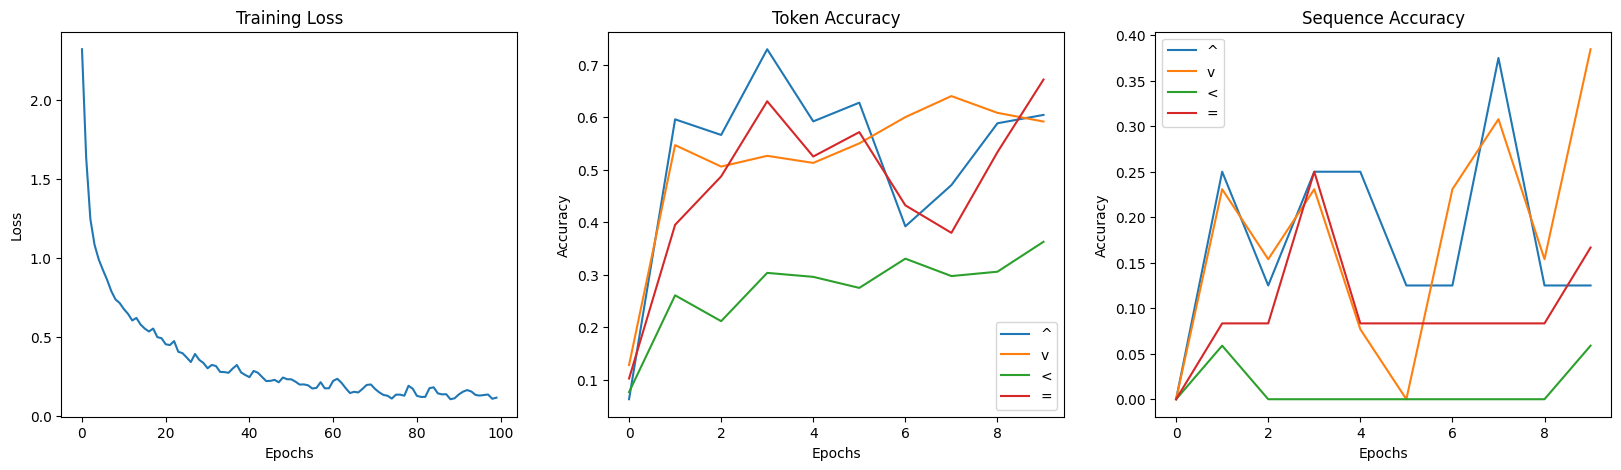

In [51]:
model = Model(vocab_size=len(wi), n_dim=128, n_head=8, layers=2, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_new_tokens=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].plot(lh, label='Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
    
tasks = ['^', 'v', '<', '=']

for i, task in enumerate(tasks):

    ax[1].plot([t[0][task] for t in tl], label=f'{task}')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Token Accuracy')

    ax[2].plot([t[1][task] for t in tl], label=f'{task}')
    ax[2].set_xlabel('Epochs')
    ax[2].set_ylabel('Accuracy')
    ax[2].set_title('Sequence Accuracy')
ax[1].legend()
ax[2].legend()
plt.show()
    

Our model have a good convergence. However, the token acuracy dont pass 80% and the sequence accuracy is very low specially for the reverse task. This lower performance is because our model is missing some layers. In our LSTM architecture:

```python
class LSTM(nn.Module):
    # ...
    def forward(self, x, state, memory):

        hidden_state = x + state

        reset_signal = self.reset_layer(hidden_state)
        reset_memory = reset_signal * memory

        set_signal = self.set_layer(hidden_state)
        value = self.value_layer(hidden_state)
        new_memory = reset_memory + set_signal * value

        # output and new state
        output = self.output_layer(hidden_state)
        new_state = output * torch.tanh(new_memory)

        return output, new_state, new_memory
```
The hidden state and memory are computed by combining previous states with current token. But the new state is computed by applying a feedforward layer to the embedding composed of the current token and the previous state. Our attention model can compute the hidden state and memory by looking at the previous tokens in the sequence, but is missing the feedforward layer to compute the new state. This is the last ingredient to built a model named Transformer that is the backbone of all the large language models we have today. Let's put the attention and feedforward layers in its own module and stack multiple layers to build our transformer model:

In [ ]:
class TransformerLayer(nn.Module):
    def __init__(self, n_dim, n_head, dff=64):
        super(TransformerLayer, self).__init__()
        self.mha = RMHA(n_dim, n_head)
        # our feed forward layer
        self.ff = nn.Sequential(
            nn.Linear(n_dim, dff, bias=False),
            nn.ReLU(),
            nn.Linear(dff, n_dim, bias=False)
        )

    def forward(self, x, m=None, freq=None, at=False):
        e = self.mha(x, m, freq)
        e = self.ff(e)
        return e


class Transformer(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20, dff=64):
        super(Transformer, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        # multiple transformer layers
        self.layers = nn.ModuleList([TransformerLayer(n_dim, n_head, dff) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        positions = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(20, 2 * freq_size / n_dim)

        self.frequencies = torch.flatten(positions.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)

    def forward(self, x, attention_mask=None):
        e = self.emb(x)
        for tl in self.layers:
            e = tl(e, self.frequencies, attention_mask)
        return self.lm(e)

    
Transformer.gen = gen

By adding the feedforward layer with a linear transformation that increases in size and then reduces it back to the original size, we are giving the model more capacity to compute the new states. This upscaling and downscaling is a common technique that helps the loss landscape to be smoother and easier to optimize and escape local minima. Also, since those layers determine the new states based on the computed information it is mostly where the model will keep its knowledge about the tasks. The attention layers are more focused on filtering relevant information from the sequence, but the feedforward layers are where the model will learn to compute the new states based on that information.

Now we can stack more layers and train it to see if it improves.

  0%|          | 0/200000 [00:00<?, ?it/s]

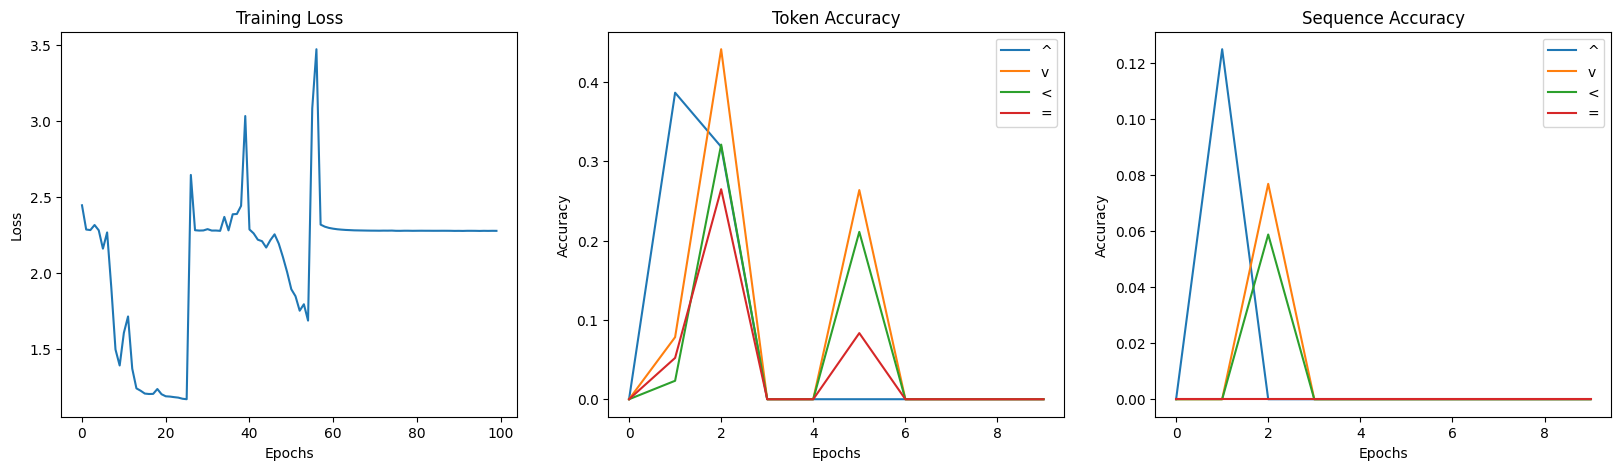

In [ ]:
model = Transformer(vocab_size=len(wi), n_dim=128, dff=128*4, n_head=8, layers=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_new_tokens=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].plot(lh, label='Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
    
tasks = ['^', 'v', '<', '=']

for i, task in enumerate(tasks):

    ax[1].plot([t[0][task] for t in tl], label=f'{task}')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Token Accuracy')

    ax[2].plot([t[1][task] for t in tl], label=f'{task}')
    ax[2].set_xlabel('Epochs')
    ax[2].set_ylabel('Accuracy')
    ax[2].set_title('Sequence Accuracy')
ax[1].legend()
ax[2].legend()
plt.show()

The model is not converging and our loss curve is not as smooth as before. This is because we are adding more layers and more parameters to our model. With more layers the gradients needs to travel throught multiple steps to update the initial weights like the embedding layers. This can cause the gradients to be increasing or decreasing in magnitude while reaching the initial layers with very high values causing it to explode or with very low values causing it to don't update at all. 

This problem was solved in the very deep architectures such as ResNets by adding skip connections that allow the gradients to travel through the network without going through all the layers. This way, the embedding layers can receive the gradients directly from the loss and compute their impact into the loss. The skip connections are just an addition of the input of the layer to its output. Since the gradient of the sum is copied to both terms, we can send gradient updates directly to the layers we want. Also, by passing the input througt multiple layers it can change its mean and variance, and we already saw that neural networks likes normalized data. So, we can also add some normalization layers before the attention and feedforward layers and after all layers to help the model to converge better. With those improvements we have our final architecture:

In [ ]:
class TransformerLayer(nn.Module):
    def __init__(self, n_dim, n_head, dff=64):
        super(TransformerLayer, self).__init__()
        self.mha = RMHA(n_dim, n_head)
        self.ff = nn.Sequential(
            nn.Linear(n_dim, dff, bias=False),
            nn.ReLU(),
            nn.Linear(dff, n_dim, bias=False)
        )
        
        # RMSNorm layers for normalization
        self.n1 = nn.RMSNorm(n_dim)
        self.n2 = nn.RMSNorm(n_dim)

    def forward(self, x, m=None, freq=None, at=False):
        # we normalize the input before the attention and feed forward layers and add a residual connection after each layer
        e = self.mha(self.n1(x), m, freq) + x
        e = self.ff(self.n2(e)) + e
        return e


class Transformer(nn.Module):
    def __init__(self, vocab_size, n_dim=16, n_head=4, layers=2, max_len=20, base_freq=20):
        super(Transformer, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.layers = nn.ModuleList([TransformerLayer(n_dim, n_head) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.n_dim = n_dim

        positions = torch.arange(0, max_len)
        freq_size = torch.arange(0, n_dim // n_head // 2)
        base_frecs = 1.0 / torch.pow(base_freq, 2 * freq_size / n_dim)

        self.frequencies = torch.flatten(positions.unsqueeze(-1) * base_frecs, end_dim=1).unsqueeze(0)
        
        self.norm = nn.RMSNorm(n_dim)

    def forward(self, x, attention_mask=None):
        e = self.emb(x)
        for tl in self.layers:
            e = tl(e, self.frequencies, attention_mask)
        
        # we also normalize after the last layer before the language modeling head
        e = self.norm(e)

        return self.lm(e)

    
Transformer.gen = gen

  0%|          | 0/200000 [00:00<?, ?it/s]

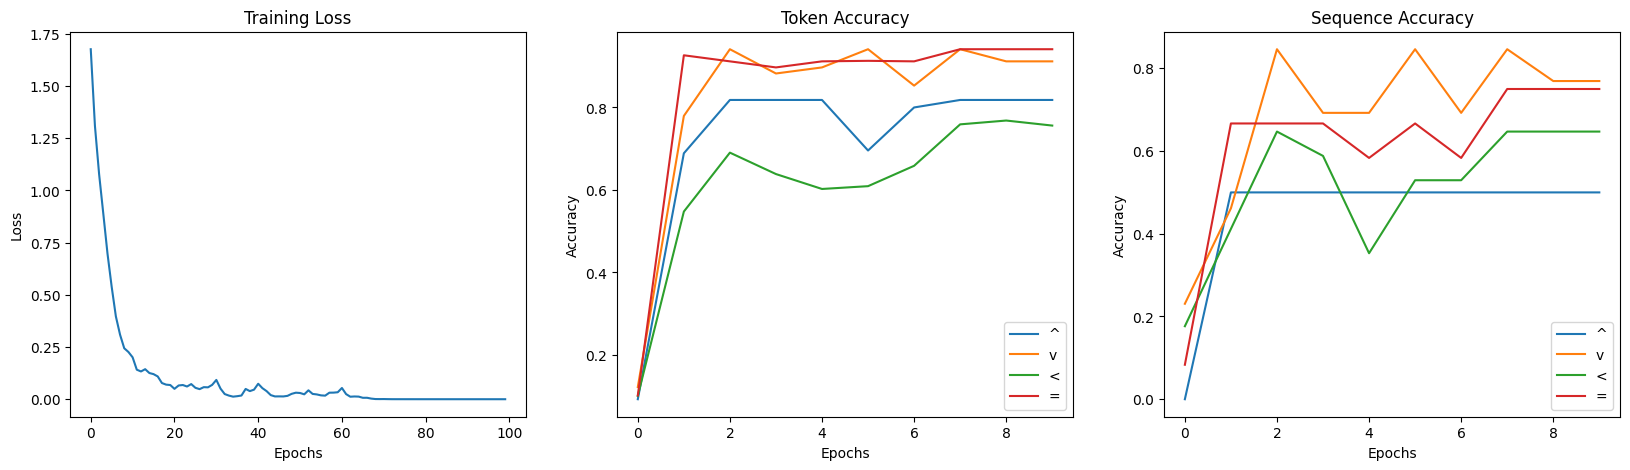

In [55]:
model = Transformer(vocab_size=len(wi), n_dim=128, n_head=8, layers=4, max_len=40)
lh, tl = lm_train(model, data, test, epochs=100, lr=0.001, batch_size=64, max_new_tokens=20)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].plot(lh, label='Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
    
tasks = ['^', 'v', '<', '=']

for i, task in enumerate(tasks):

    ax[1].plot([t[0][task] for t in tl], label=f'{task}')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Token Accuracy')

    ax[2].plot([t[1][task] for t in tl], label=f'{task}')
    ax[2].set_xlabel('Epochs')
    ax[2].set_ylabel('Accuracy')
    ax[2].set_title('Sequence Accuracy')
ax[1].legend()
ax[2].legend()
plt.show()

Our model is now converging and learning well. We can also check the performance in the test dataset and see that it reaches near 100% accuracy in the uppercase and lowercase tasks and around 90% in the copy and reverse tasks. In the sequence accuracy it still have difficulties in the copy and reverse tasks, but it is a great improvement compared to the previous model without the feedforward layers.

## Language modeling with transformers

Now that we have an improved architecture capable of efficiently language modeling, we can now train it in the wikipedia pages. Since it is more efficient we can also add more pages to our dataset and train it in more data. The more data we have more knowledge we can insert into our model and the better it will perform. Let's prepare our dataset.

In [56]:
import requests
 
# using more pages
urls = [
    'https://en.wikipedia.org/wiki/Computer',
    'https://en.wikipedia.org/wiki/Operating_system',
    'https://en.wikipedia.org/wiki/Computer_hardware',
    'https://en.wikipedia.org/wiki/Software',
    'https://en.wikipedia.org/wiki/Central_processing_unit',
    'https://en.wikipedia.org/wiki/Computer_memory',
    'https://en.wikipedia.org/wiki/Turing_machine',
    'https://en.wikipedia.org/wiki/Trigonometric_functions'
]

texts = []
for url in urls:
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    texts.append(response.text)

In [ ]:
from bs4 import BeautifulSoup
import re

prompts = []

for text in texts:
    doc = BeautifulSoup(text, 'html.parser')
    body = doc.find(id='bodyContent')
    prompts.append(body.get_text())

cleaned_text = re.sub(r'\n+', '\n', '\n\n'.join(prompts))
print(len(cleaned_text))

490086


We have almost 500k characters in our dataset. We can train the model to predict the next characters as we have done since the first chapter. However, from the n-gram example if we increase the size of the n-gram we can compress our training data since one token can represent multiple characters. However, n-grams have a fixed size and we can achieve further compression without sacrificing the generalization of our model if we use a better tokenizer technique.

One of the tokenization techniques most used in modern models is the byte pair encoding (BPE). It works by starting with a sequence of characters as we have done, but iteratively merging the most common pairs of tokens into a single token until we reach a desired vocabulary size. To achieve further representation capacity, instead of using the character index as the token index, we can use the byte representation of the characters in utf-8 for example. This way we can represent all characters in multiple languages and even emojis.

Let's start our implementation of the BPE tokenizer. The first step is counting the frequency of the pairs that we will be merging.

In [59]:
from collections import Counter

def pair_counts(tokens):
    count = Counter()

    for i in range(len(tokens) - 1):
        count[(tokens[i], tokens[i + 1])] += 1

    return count

Now, we nee to write a function that traverses the whole sequence of tokens merging the most frequent pair and replace the pair by a new token id.

In [60]:
# a pair of tokens is just a tuple (token1, token2)
def merge_pair(tokens, pair, new_id):
    new_tokens = []
    i = 0
    # we iterate through the whole list of tokens
    while i < len(tokens):
        # if the current pair of tokens is equal to the pair we want to merge, we add the new token list
        if i < len(tokens) - 1 and (tokens[i], tokens[i + 1]) == pair:
            new_tokens.append(new_id)
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1

    return new_tokens

With those functions we can now train our tokenizer. First, we encode our text into utf-8 bytes and get the byte representation of each character. Our vocabulary starts as all bytes from 0 to 255 and with each new pair we increase it by one. Then we find the most common pair and merge it until we reach the desired vocabulary size. We need also to save the merging rules to be able to tokenize new text in the future.

In [ ]:
from tqdm.auto import tqdm

def bpe(text, vocab_size):
    # we start with the byte encoding of the text
    tokens = list(text.encode('utf-8'))
    merges = {}
    # initially our vocabulary is just the byte encoding of the characters
    vocab = {i: bytes([i]) for i in range(256)}

    for _ in tqdm(range(vocab_size - len(vocab))):
        # conting pair frequencies
        pc = pair_counts(tokens)
        # finding the most common pair of tokens to merge
        mc = pc.most_common(1)[0][0]
        # new token id
        nid = len(vocab) + 1
        # merging the most common pair of tokens in the list
        tokens = merge_pair(tokens, mc, nid)
        
        vocab[nid] = vocab[mc[0]] + vocab[mc[1]]
        merges[mc] = nid

    return vocab, merges

vocab, merges = bpe(cleaned_text, 1000)

  0%|          | 0/744 [00:00<?, ?it/s]

With our merge rules we can encode a text by iterativelly applying the merging rules in the same order we learn them. This takes some time since we will do multiples traversals in the entire text.

In [ ]:
def encode(tokens, merges):
    tks = list(tokens.encode('utf-8'))

    while len(tks) >= 2:
        mc = pair_counts(tks).most_common(1)[0][0]
        if mc not in merges:
            break
        tks = merge_pair(tks, mc, merges[mc])

    return tks

encoded_text = encode(cleaned_text, merges)
print(len(encoded_text))
print(f'Reduction of: {1 - len(encoded_text) / len(cleaned_text):.2f}%')

196778


We cut our initial text size by 60% with a vocabulary of 1000 tokens. We can compress further by increasing the vocabulary size. Decoding the text is easy as we need just to look at the token id and replace it with the corresponding text from the vocabulary.

In [233]:
def decode(tokens, vocab):
    return b''.join([vocab[t] for t in tokens]).decode('utf-8', errors='ignore')

dt = decode(encoded_text, vocab)
# let's check if the decoded text is the same as the original cleaned text
print(dt[:1000] == cleaned_text[:1000])
print(dt[:1000])


False
A empadinha de camarao me lembra tanto


Let's check how our tokenizer is working by encoding and decoding a sample text:

In [72]:
print([vocab[t].decode('utf-8') for t in encoded_text[:100]])

['\nF', 'rom', ' ', 'W', 'ik', 'ip', 'edi', 'a', ', the ', 'f', 're', 'e ', 'enc', 'yc', 'lo', 'p', 'edi', 'a', '\nP', 'ro', 'gram', 'ma', 'b', 'le ', 'machine ', 'that ', 'process', 'es ', 'dat', 'a', '\nF', 'or ', 'the ', 'con', 's', 'um', 'er', '-', 'or', 'i', 'ent', 'ed ', 'devic', 'e ', 'which ', 'is ', 'also ', 'c', 'alled ', 'a ', 'comput', 'er, ', 'se', 'e ', 'P', 'ers', 'on', 'al ', 'computer', '.\n', 'F', 'or ', 'other ', 'us', 'es, ', 'se', 'e ', 'Computer ', '(', 'dis', 'am', 'b', 'ig', 'u', 'ation', ')', '.\n', 'Comput', 'ers ', 'and ', 'comput', 'ing ', 'devic', 'es ', 'from ', 'differ', 'ent ', 'er', 'as', '—', 'le', 'f', 't ', 'to ', 'righ', 't', ', ', 'top', ' to ', 'bo']


It is learning to encoding some words like "machine", and "process". However, it is also splitting ", the " as a single token. Spliting outside word boundaries will makes harder for our model to learn the structure of the language. To solve this problem we can restrict the merging of tokens only inside word boundaries. For that we need to pre-tokenize our text into words and we apply the merging process in chunks.

We can use regex to pre-tokenize our text and use the same rule used in GPT-2. Also, the spaces before words are added to the word itself for further compression.

In [74]:
import re

GPT2_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?\d+| ?[^\s\w\d]+|\s+"""

text = "A computer is a machine that can be programmed"
chunks = re.findall(GPT2_PATTERN, text)
print(chunks)

['A', ' computer', ' is', ' a', ' machine', ' that', ' can', ' be', ' programmed']


Let's update our bpe learning and use more tokens in the vocabulary to see how it performs.

In [76]:
def pbpe(tokens, vocab_size):

    # we start with the byte encoding of the text and we split it into chunks using the GPT2 pattern
    chunks = [list(q.encode('utf-8')) for q in re.findall(GPT2_PATTERN, tokens)]
    merges = {}
    vocab = {i: bytes([i]) for i in range(256)}

    for _ in tqdm(range(vocab_size - len(vocab))):
        fc = Counter()
        # the frequency is also counted over all chunks
        for q in chunks:
            fc.update(pair_counts(q))
        if len(fc) == 0:
            break
        mc = fc.most_common(1)[0][0]
        nid = len(vocab)
        # but the merging rules are applied per chunk
        # this way there is no splitting between word boundaries
        chunks = [q if len(q) <= 1 else merge_pair(q, mc, nid) for q in chunks]
        vocab[nid] = vocab[mc[0]] + vocab[mc[1]]
        merges[mc] = nid

    return vocab, merges


vocab, merges = pbpe(cleaned_text, 2000)

  0%|          | 0/1744 [00:00<?, ?it/s]

We need to update also our encoding and decoding functions to use the new pre-tokenization.

In [83]:
def pencode(tokens, merges):
    tks = re.findall(GPT2_PATTERN, tokens)
    at = []
    for q in tks:
        q = list(q.encode('utf-8'))
        while len(q) >= 2:
            fc = pair_counts(q)
            mc = fc.most_common()
            bc = None

            for c, _ in mc:
                if c in merges:
                    if bc is None or merges[c] < merges[bc]:
                        bc = c

            if bc is None:
                break
            q = merge_pair(q, bc, merges[bc])
        at.extend(q)

    return at

In [238]:
encoded_text = pencode(cleaned_text, merges)
print(len(encoded_text))
print(f'Reduction of: {1 - len(encoded_text) / len(cleaned_text):.2f}%')

dt = decode(encoded_text, vocab)
print(dt[:500] == cleaned_text[:500])
print(dt[:500])


170874
Reduction of: 0.65%
True

From Wikipedia, the free encyclopedia
Programmable machine that processes data
For the consumer-oriented device which is also called a computer, see Personal computer.
For other uses, see Computer (disambiguation).
Computers and computing devices from different eras—left to right, top to bottom:
Early vacuum-tube computer (ENIAC)Mainframe computer (IBM System/360)Smartphone (LYF Water 2)Desktop computer (IBM ThinkCentre S50 with monitor)Supercomputer (IBM Summit)
A computer is a machine that ca


Our encoding is also faster. Let's verify the splitting of the tokens in the sample text:

In [240]:
print([vocab[t].decode('utf-8') for t in encoded_text[:100]])

['\n', 'F', 'rom', ' Wik', 'ipedia', ',', ' the', ' f', 'ree', ' en', 'cyclopedia', '\n', 'Pro', 'grammable', ' machine', ' that', ' process', 'es', ' data', '\n', 'For', ' the', ' cons', 'umer', '-', 'or', 'i', 'ent', 'ed', ' device', ' which', ' is', ' also', ' called', ' a', ' computer', ',', ' see', ' P', 'ersonal', ' computer', '.', '\n', 'For', ' other', ' uses', ',', ' see', ' Computer', ' (', 'dis', 'am', 'b', 'ig', 'u', 'ation', ').', '\n', 'Comput', 'ers', ' and', ' computing', ' devices', ' from', ' different', ' er', 'as', '—', 'left', ' to', ' right', ',', ' to', 'p', ' to', ' b', 'ot', 't', 'om', ':', '\n', 'E', 'arly', ' v', 'acuum', '-', 't', 'ub', 'e', ' computer', ' (', 'E', 'NIAC', ')', 'Main', 'f', 'ram', 'e', ' computer', ' (']


Now we can train our transformer in the wikipedia dataset with the new tokenizer. Let's prepare the dataset and train the model.

In [242]:
context_size = 64
answers = []
attention_mask = []
prompt_mask = []
for i in range(0, len(encoded_text) - context_size, 32):
    answers.append(encoded_text[i:i + context_size])
    attention_mask.append([0] * context_size)
    prompt_mask.append([1] * context_size)

wdata = TensorDataset(torch.LongTensor(answers), torch.Tensor(attention_mask), torch.Tensor(prompt_mask))

Now we can train our model. Since we are training in a large dataset in the CPU it will take about 30 minutes to train.

  0%|          | 0/266900 [00:00<?, ?it/s]

0.4047641475757439


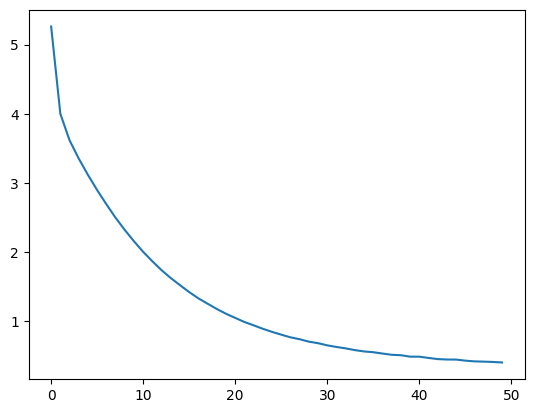

In [256]:
model = Transformer(vocab_size=len(vocab), n_dim=128, n_head=8, layers=4, max_len=80, base_freq=1000)
lh, tl = lm_train(model, wdata, None, epochs=50, lr=0.001, batch_size=16)

print(lh[-1])
plt.plot(lh)
plt.show()

Our model learned and to sample text from it we need to update the generation function to use the new tokenizer.

In [ ]:
def gen(self, s, v, m, max_len=10):
    
    tokens = [pencode(q, m) for q in s]
    
    ma = [[0] * len(q) for q in tokens]
    ml = max([len(q) for q in tokens])
    
    tokens = [[0] * (ml - len(q)) + q for q in tokens]
    ma = [[1] * (ml - len(q)) + q for q in ma]

    x1 = torch.LongTensor(tokens)
    x2 = torch.Tensor(ma)
    
    for _ in range(max_len):
        with torch.no_grad():            
            o = self(x1, x2)
            
        new_token = torch.multinomial(o[:, -1].exp(), num_samples=1)
        x1 = torch.cat([x1, new_token], dim=1)
        x2 = torch.cat([x2, torch.zeros(x1.shape[0], 1)], dim=1)
    
    res = []
    for q, w in zip(x1, x2):
        res.append([q[i].item() for i in range(len(q)) if w[i].item() == 0])
        
    return [decode(q, v) for q in res]

prompts = ['A computer is a machine that']

print(gen(model, prompts, vocab, merges, max_len=100, bs=16)[0]) 

A computer is a machine that is a vector to perform a single machine operation uniqueue to perform a simplary.[38] There, the moving this to write data, making human-toiltile writing the kernel generallyever, which performded. This notion. Edition. However, each combined that-tangent by the kernel detach into an these early computers can be set of external wapearfusually of memory, numbers (hich are


## Conclusion

In this chapter we have seen how the attention mechanism works and how it can be used to build a more efficient model for language modeling. We have also seen how to train our model to perform some analytic tasks by just training it to predict the next token in the sequence. Finally, we have seen how to use a better tokenizer to compress our training data and improve the performance of our model. With all these improvements we have built a transformer model that is the backbone of all the large language models we have today.

However, to achieve a higher performance we need to scale both our dataset and our model parameters. With more data we can insert more knowledge into our model and with more parameters we can increase the capacity of our model to learn from that data. In the next chapter we will see how to scale our model and dataset to achieve a better performance using GPU acceleration.